## Module 23: Principal Component Analysis

### Dataset: Wine Quality Dataset

In [ ]:
# Done for you

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

df = wine.frame

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### TODO 1: Explore the Dataset

In [ ]:
# TODO

# Display dataset shape
print(df.shape)
# Display first few rows
print(df.head(10))
# Display data types
print(df.dtypes)


# Display class distribution
print(df['target'].value_counts())


(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   
5    14.20        1.76  2.45               15.2      112.0           3.27   
6    14.39        1.87  2.45               14.6       96.0           2.50   
7    14.06        2.15  2.61               17.6      121.0           2.60   
8    14.83        1.64  2.17               14.0       97.0           2.80   
9    13.86        1.35  2.27               16.0       98.0           2.98   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29           

### TODO 2 : Feature Correlation

In [ ]:
# TODO


# Calculate correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

# Display highly correlated features


                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
target                       -0.328222    0.437776 -0.049643   

                              alcalinit

### TODO 3 : Standardization

In [ ]:
from re import X
from sklearn.preprocessing import StandardScaler

# TODO

# Separate X and y
X = df.drop('target', axis=1)
y = df['target']

# Standardize X
scaler = StandardScaler()

# Apply StandardScaler

X_scaled = scaler.fit_transform(X)

### TODO 4 : Apply PCA

In [ ]:
from sklearn.decomposition import PCA

# TODO

# Apply PCA
np.set_printoptions(suppress=True)
pca = PCA(n_components=None)
X_pca_FULL = pca.fit_transform(X_scaled)
print(X_pca_FULL)
# Display explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

# Display number of principal components

print(pca.n_components_)    #মোট কতগুলো Principal Component তৈরি হয়েছে তা দেখায়।



[[ 3.31675081  1.44346263 -0.16573904 ... -0.4515634   0.54081041
  -0.06623863]
 [ 2.20946492 -0.33339289 -2.02645737 ... -0.14265731  0.38823774
   0.0036365 ]
 [ 2.51674015  1.0311513   0.98281867 ... -0.28667285  0.00058357
   0.02171651]
 ...
 [-2.67783946  2.76089913 -0.94094188 ...  0.51249202  0.69876645
   0.07207769]
 [-2.38701709  2.29734668 -0.5506962  ...  0.29982197  0.33982065
  -0.02186576]
 [-3.20875816  2.76891957  1.01391366 ... -0.22996433 -0.18878796
  -0.32396472]]
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]
13


### TODO 5 : Cumulative Variance

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


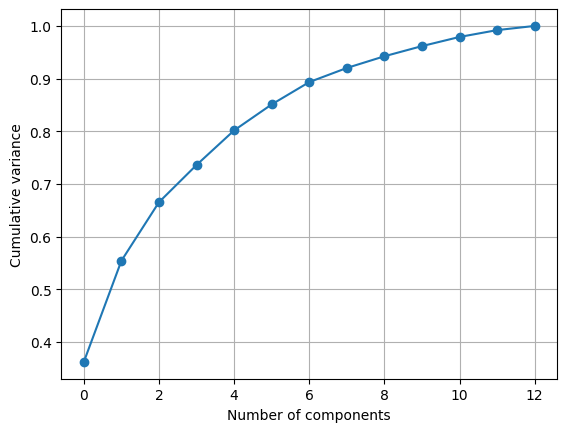

In [ ]:
# TODO

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance_ratio)

print(cumulative_variance)
# Plot cumulative variance graph
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.grid()
plt.show()


### TODO 6 : Logistic Regression WITHOUT PCA

In [ ]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

# TODO using pipeline perform these tasks

# Train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,y,test_size=0.2,random_state=42,stratify=y)

# Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])
# StandardScaler
scaler=StandardScaler()
# Fit
pipe_no_pca.fit(X_train,y_train)
# Predict
y_pred = pipe_no_pca.predict(X_test)

# Logistic Regression

# Calculate Accuracy
acc_no_pca = accuracy_score(y_test,y_pred)
print(acc_no_pca)


0.9722222222222222


### TODO 7 : Logistic Regression WITH PCA

In [ ]:
# TODO

# StandardScaler
pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=8)),
    ("clf", LogisticRegression(max_iter=500))
])
# PCA(95% rakhte joto gula component lage totogulo use kore)
pipe_with_pca.fit(X_train,y_train)
# Predict
y_pred = pipe_with_pca.predict(X_test)
# Logistic Regression

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9722222222222222


### TODO 8 : Compare Results

In [ ]:
# TODO

# Create a small comparison table

# Without PCA

# With PCA

# Accuracy

# Number of Features




| Model       | Accuracy | Number of Features |
| ----------- | -------: | -----------------: |
| Without PCA |   0.9722 |                 13 |
| With PCA    |   0.9722 |                  8 |

### এর মানে কী?

* **Without PCA:** 13টি original feature ব্যবহার করেছে।
* **With PCA:** মাত্র **8টি principal component** ব্যবহার করেছে।(eight)
* **Accuracy একই (0.9722)**।

অর্থাৎ,

> **PCA 13টি feature থেকে 8টিতে নামিয়ে এনেছে, কিন্তু Accuracy কমেনি।**

এটাই PCA-এর মূল সুবিধা:

* ✅ Feature কমায়
* ✅ Noise কমাতে সাহায্য করে
* ✅ Model দ্রুত train হতে পারে
* ✅ Accuracy অনেক সময় একই থাকে বা সামান্য পরিবর্তন হয়

তোমার assignment-এর শেষ প্রশ্নে লিখতে পারো:

> **Without PCA:** Accuracy = **0.9722**, Features = **13**
> **With PCA:** Accuracy = **0.9722**, Features = **8**
> **Conclusion:** PCA feature সংখ্যা **13 থেকে 8**-এ কমিয়েছে, কিন্তু model-এর accuracy একই (**97.22%**) রেখেছে। তাই PCA dimensionality কমিয়েও গুরুত্বপূর্ণ তথ্য ধরে রাখতে পেরেছে।


Q: In this dataset, would you recomment PCA? Justify and explain your observation


A:Yes. I recommend PCA because it reduced the features from 13 to 8, but the accuracy remained the same (97.22%). This shows that the removed features were not very important, and PCA preserved the important information while reducing dimensionality.

খুব ভালো প্রশ্ন। এখানেই অনেকেই confused হয়।

তুমি করেছ:

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca_FULL = pca.fit_transform(X_scaled)
```

এখানে **StandardScaler** করার কারণ **`explained_variance_ratio_` বের করা নয়**।

বরং **PCA যেন সঠিকভাবে variance হিসাব করতে পারে**, সেই জন্য।

ধরো তোমার dataset-এ:

| Feature | Range      |
| ------- | ---------- |
| Alcohol | 11 - 14    |
| Proline | 278 - 1680 |

এখানে **Proline-এর variance অনেক বেশি**।

যদি তুমি সরাসরি করো:

```python
pca.fit_transform(X)
```

তাহলে PCA ভাববে **Proline-ই সবচেয়ে গুরুত্বপূর্ণ feature**, কারণ তার variance সবচেয়ে বেশি।

কিন্তু যদি আগে করো:

```python
X_scaled = scaler.fit_transform(X)
```

তাহলে সব feature-এর scale একই হয়ে যাবে (mean ≈ 0, std ≈ 1)।

এরপর:

```python
pca.fit_transform(X_scaled)
```

এখন PCA **সব feature-কে সমানভাবে বিবেচনা করে** principal component বের করবে।

---

### তাহলে `explained_variance_ratio_` কোথা থেকে আসে?

এটা `pca.fit()` করার সময় PCA নিজেই হিসাব করে এবং `pca` object-এর মধ্যে রেখে দেয়।

```python
pca.fit_transform(X_scaled)
```

এরপর তুমি শুধু সেটা পড়ছ:

```python
print(pca.explained_variance_ratio_)
```

---

### সহজ করে মনে রাখো

* **StandardScaler** ➜ Data-এর scale সমান করে।
* **PCA** ➜ সেই scaled data থেকে principal components বের করে।
* **`explained_variance_ratio_`** ➜ PCA কত শতাংশ variance প্রতিটি principal component ধরে রেখেছে, সেটার ফলাফল।

অর্থাৎ **StandardScaler-এর কাজ `explained_variance_ratio_` তৈরি করা নয়**, বরং **PCA যেন সঠিক `explained_variance_ratio_` বের করতে পারে, সেই জন্য data প্রস্তুত করা।**


# scaling ere kaj


এখানেই একটু কনফিউশন হয়েছে। **আসলে `x_scaled`-ই ব্যবহার হচ্ছে।**

তোমার কোড:

```python
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca_full = PCA(n_components=None)

x_pca_full = pca_full.fit_transform(x_scaled)
```

এখানে `fit_transform(x_scaled)`-এ **`x_scaled`-ই input**।

এটা ভিতরে দুইটা কাজ করে:

```text
pca_full.fit(x_scaled)      # PCA শেখে (variance, components বের করে)
            +
pca_full.transform(x_scaled) # Data-কে PC1, PC2... এ রূপান্তর করে
```

অর্থাৎ,

```python
x_pca_full = pca_full.fit_transform(x_scaled)
```

এটা সমান:

```python
pca_full.fit(x_scaled)
x_pca_full = pca_full.transform(x_scaled)
```

---

তারপর তুমি লিখেছো:

```python
explained_part = pca_full.explained_variance_ratio_
```

এটা `fit(x_scaled)`-এর সময় হিসাব করা variance ratio।

অর্থাৎ Flow হলো:

```text
x
 ↓
StandardScaler
 ↓
x_scaled
 ↓
PCA.fit(x_scaled)
    ├── explained_variance_ratio_
    ├── principal components
    └── eigenvectors
 ↓
PCA.transform(x_scaled)
 ↓
x_pca_full
```

### তাহলে `x_pca_full` কেন `x_scaled` নয়?

কারণ:

* **`x_scaled` = Scaled original features (এখনও ৩০টি feature)**
* **`x_pca_full` = PCA-এর পরে নতুন Principal Components (PC1, PC2, ...)**

উদাহরণ:

আগে:

```text
x_scaled
Radius  Texture  Area
```

PCA-এর পরে:

```text
x_pca_full
PC1  PC2  PC3 ...
```

**অর্থাৎ `x_scaled` ইনপুট, আর `x_pca_full` হলো আউটপুট।**

**এক লাইনে মনে রাখো:**

> **PCA সবসময় `x_scaled`-এর উপর `fit` করে, আর সেই `x_scaled`-কেই `transform` করে `x_pca_full` বানায়।**


**না, `x_pca_full` হবে না।**

কারণ:

```python
explained_part = pca_full.explained_variance_ratio_
```

এটি **কোনো input নেয় না**। এটি `fit()` করার সময় PCA যে information শিখেছে, সেটি object থেকে বের করে।

দেখো:

```python
pca_full = PCA()

pca_full.fit(x_scaled)      # PCA শেখে

pca_full.explained_variance_ratio_
```

এখন প্রশ্ন হলো, `x_pca_full` কোথায়?

```python
x_pca_full = pca_full.transform(x_scaled)
```

বা

```python
x_pca_full = pca_full.fit_transform(x_scaled)
```

এটি **PCA-এর output data**।

---

### পার্থক্য

```python
x_scaled
```

➡️ PCA-এর **Input**

```python
x_pca_full
```

➡️ PCA-এর **Output** (PC1, PC2, ...)

```python
explained_variance_ratio_
```

➡️ প্রতিটি PC কত % variance ধরে রেখেছে, সেই তথ্য।

---

### উদাহরণ

ধরো,

```python
x_scaled.shape
```

```
(569, 30)
```

PCA করার পর,

```python
x_pca_full.shape
```

```
(569, 30)
```

(যদি `n_components=None` হয়)

এখন,

```python
pca_full.explained_variance_ratio_
```

Output:

```python
[0.44, 0.19, 0.09, 0.07, ...]
```

এখানে:

* **0.44** → PC1-এর variance ratio
* **0.19** → PC2-এর variance ratio
* **0.09** → PC3-এর variance ratio

এগুলো `x_pca_full` থেকে আলাদা করে বের করতে হয় না, কারণ `fit()` করার সময় PCA এগুলো **আগেই হিসাব করে object-এর ভিতরে সংরক্ষণ করেছে**।

### সহজ নিয়ম

```text
x_scaled
    │
    ▼
fit_transform()
    │
    ├── x_pca_full  ← নতুন transformed data
    │
    └── explained_variance_ratio_ ← প্রতিটি PC কত variance ধরে রেখেছে
```

**এক লাইনে:**

> **`x_pca_full` হলো transformed dataset, আর `explained_variance_ratio_` হলো PCA model-এর একটি attribute। তাই এখানে `x_pca_full` ব্যবহার করা লাগে না।**


# confusion fit_tranform



এখানেই মূল কনসেপ্টটা। ধীরে ধীরে বোঝাই।

তোমার কোড:

```python
pca = PCA(n_components=None)

X_pca_FULL = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
```

তুমি জিজ্ঞেস করছো:

> **`fit_transform()` একসাথে কেন করলাম? আর `explained_variance_ratio_`-এর সময় `pca` কেন ব্যবহার করছি?**

---

## ১. `fit_transform()` কেন?

`fit_transform()` = **fit + transform**

এটি লেখার শর্টকাট।

অর্থাৎ,

```python
pca.fit(X_scaled)
X_pca_FULL = pca.transform(X_scaled)
```

এবং

```python
X_pca_FULL = pca.fit_transform(X_scaled)
```

**একই কাজ।**

---

## ২. `fit()` কী করে?

```python
pca.fit(X_scaled)
```

এখানে PCA শিখে:

* কোন direction-এ variance বেশি
* PC1, PC2, PC3...
* explained_variance_ratio
* components

এগুলো **`pca` object-এর ভিতরে save করে রাখে।**

---

## ৩. `transform()` কী করে?

```python
pca.transform(X_scaled)
```

এটি `X_scaled`-কে নতুন Principal Components-এ রূপান্তর করে।

Output:

```python
X_pca_FULL
```

---

## ৪. `explained_variance_ratio_`-এ `pca` কেন?

কারণ **`explained_variance_ratio_` হলো `pca` object-এর property (attribute)।**

যখন তুমি

```python
pca.fit(X_scaled)
```

করেছিলে, তখনই PCA এটা হিসাব করে নিজের ভিতরে রেখে দিয়েছে।

তাই পরে শুধু লিখলেই হয়:

```python
pca.explained_variance_ratio_
```

---

### একটা বাস্তব উদাহরণ

ধরো একজন ছাত্র পরীক্ষা দিল।

```text
Student
   │
   ▼
Exam দিল (fit)
```

এখন পরীক্ষার ফল ছাত্রের কাছেই আছে।

তুমি যদি জানতে চাও GPA,

তাহলে বলবে:

```text
student.gpa
```

তুমি আবার পরীক্ষা দাও না!

ঠিক তেমনি,

```python
pca.fit(X_scaled)
```

এরপর

```python
pca.explained_variance_ratio_
```

শুধু সেই সংরক্ষিত ফল বের করে।

---

## সহজ Flow

```text
X_scaled
    │
    ▼
pca.fit()
    │
    ├── explained_variance_ratio_  ← pca-এর ভিতরে save
    ├── components_
    └── n_components_
    │
    ▼
pca.transform()
    │
    ▼
X_pca_FULL
```

### **মনে রাখার নিয়ম**

* **`fit()` → শেখে এবং তথ্য `pca` object-এ সংরক্ষণ করে।**
* **`transform()` → data-কে নতুন Principal Components-এ পরিবর্তন করে।**
* **`explained_variance_ratio_` → `fit()`-এ সংরক্ষিত তথ্য, তাই `pca` object থেকেই নেওয়া হয়।**


চলো খুব ছোট একটা উদাহরণ দেখি।

ধরো তোমার data:

| Height | Weight |
| -----: | -----: |
|    160 |     50 |
|    170 |     60 |
|    180 |     70 |

---

## Step 1: `fit()`

```python
pca.fit(X_scaled)
```

এখানে **data পরিবর্তন হয় না।**

PCA শুধু শিখে:

* কোন direction-এ variance সবচেয়ে বেশি?
* PC1 কী হবে?
* PC2 কী হবে?
* explained_variance_ratio কত?

এগুলো `pca` object-এর ভিতরে save হয়।

ধরো PCA শিখল:

```text
PC1 = 0.7 × Height + 0.7 × Weight
PC2 = 0.7 × Height − 0.7 × Weight

explained_variance_ratio = [0.95, 0.05]
```

এগুলো শুধু **মেমরিতে সংরক্ষিত** হলো।

---

## Step 2: `transform()`

```python
X_pca = pca.transform(X_scaled)
```

এখন original data

```text
Height  Weight
160      50
170      60
180      70
```

পরিবর্তিত হয়ে হয়ে গেল

```text
PC1    PC2
2.15   0.08
3.45  -0.02
4.72  -0.06
```

এটাই **`X_pca`**।

---

## Step 3: `fit_transform()`

```python
X_pca = pca.fit_transform(X_scaled)
```

এটি এক লাইনে দুই কাজ করে:

1. `fit(X_scaled)` → PCA শিখল।
2. `transform(X_scaled)` → Data-কে PC-তে পরিবর্তন করল।

---

### মনে রাখার সহজ উদাহরণ

ধরো একজন শিক্ষক।

📖 **`fit()`** = শিক্ষক বই পড়ে শিখছেন।

📝 **`transform()`** = শেখা জ্ঞান ব্যবহার করে ছাত্রদের পরীক্ষা নিচ্ছেন।

একইভাবে,

* **`fit()`** → PCA data থেকে শেখে।
* **`transform()`** → সেই শেখা ব্যবহার করে data-কে Principal Components-এ রূপান্তর করে।

**এক লাইনে:**

> **`fit()` = Learn (শেখা), `transform()` = Apply (শেখা প্রয়োগ করে data পরিবর্তন করা)।**
